In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.utils import compute_sample_weight
from xgboost import XGBClassifier

In [2]:
sns.set_theme(style="whitegrid", rc={"figure.figsize":(10, 6)})

df = pd.read_csv("Data/nashville_sample.csv", low_memory=False)
print(f"Kolumny danych:\n{df.columns.values}\n")

Kolumny danych:
['time' 'precinct' 'subject_age' 'subject_race' 'subject_sex' 'violation'
 'arrest_made' 'citation_issued' 'warning_issued' 'outcome'
 'contraband_found' 'contraband_drugs' 'contraband_weapons'
 'frisk_performed' 'search_conducted' 'search_basis' 'reason_for_stop']



# Klasyfikacja

In [3]:
df = pd.read_csv("Data/nashville_sample.csv", low_memory=False)

df["time_obj"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")
df["hour_of_day"] = df["time_obj"].dt.hour
df = df.dropna(subset=["hour_of_day"])
df["hour_of_day"] = df["hour_of_day"].astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day']/24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day']/24.0)

features = ["subject_age", "subject_race", "subject_sex", "hour_sin", "hour_cos", "violation", "contraband_found", 'search_conducted']
target = "outcome"

df_clean = df[features + [target]].dropna(subset=[target])

X = df_clean[features]
y = df_clean[target]

numeric_features = ["subject_age", "hour_sin", "hour_cos"]
categorical_features = ["subject_race", "subject_sex", "violation", "contraband_found", 'search_conducted']

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Liczba próbek treningowych: {len(X_train)}")
print(f"Liczba próbek testowych: {len(X_test)}")

Liczba próbek treningowych: 34086
Liczba próbek testowych: 8522



--- Raport Klasyfikacji ---
              precision    recall  f1-score   support

      arrest       0.32      0.70      0.44       141
    citation       0.36      0.53      0.43      1872
     warning       0.85      0.71      0.77      6509

    accuracy                           0.67      8522
   macro avg       0.51      0.65      0.55      8522
weighted avg       0.73      0.67      0.69      8522

--- Macierz Pomyłek ---


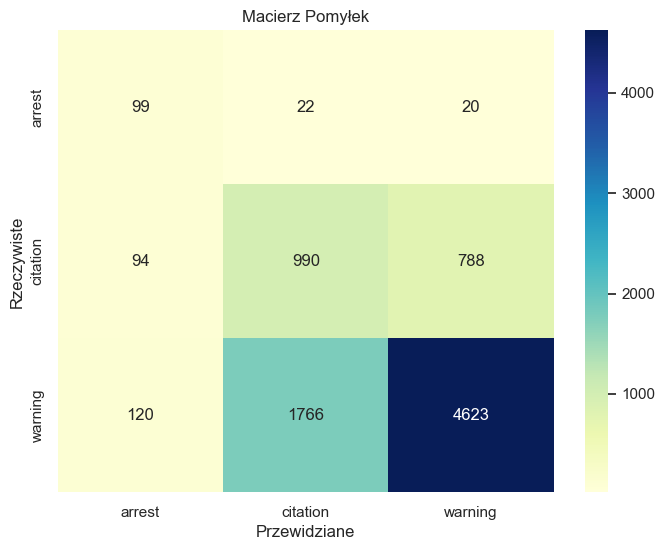

In [4]:
model_pipeline = ImbPipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        min_samples_leaf=4,
        class_weight="balanced",
        n_jobs=-1
    )),
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print("\n--- Raport Klasyfikacji ---")
print(classification_report(y_test, y_pred))

print("--- Macierz Pomyłek ---")
cm = confusion_matrix(y_test, y_pred)
class_labels = model_pipeline.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Macierz Pomyłek')
plt.xlabel('Przewidziane')
plt.ylabel('Rzeczywiste')
plt.show()

 # Regresja

Trenowanie Regresji Logistycznej...


C:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Raport Klasyfikacji (Logistic Regression) ---
              precision    recall  f1-score   support

      arrest       0.03      0.47      0.06       140
    citation       0.31      0.58      0.40      1862
     warning       0.89      0.40      0.55      6464

    accuracy                           0.44      8466
   macro avg       0.41      0.49      0.34      8466
weighted avg       0.75      0.44      0.51      8466



C:\Users\bruno\AppData\Local\Temp\ipykernel_25936\1054223600.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Wpływ (Waga)', y='Cecha', data=coef_df, palette='coolwarm')


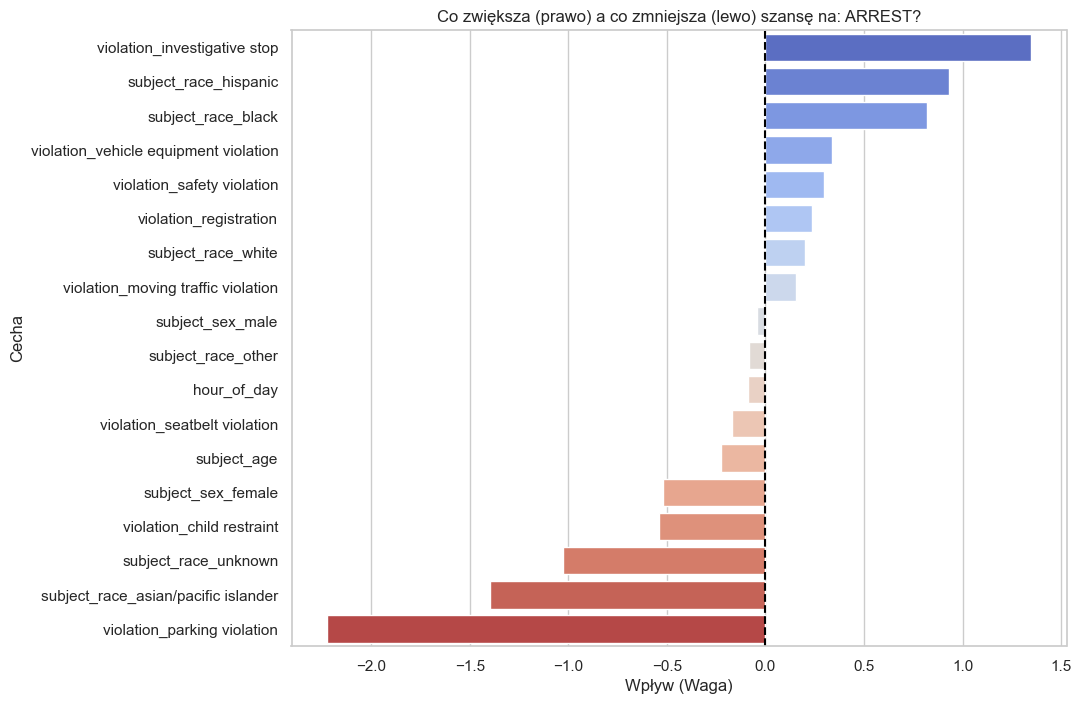

C:\Users\bruno\AppData\Local\Temp\ipykernel_25936\1054223600.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Wpływ (Waga)', y='Cecha', data=coef_df, palette='coolwarm')


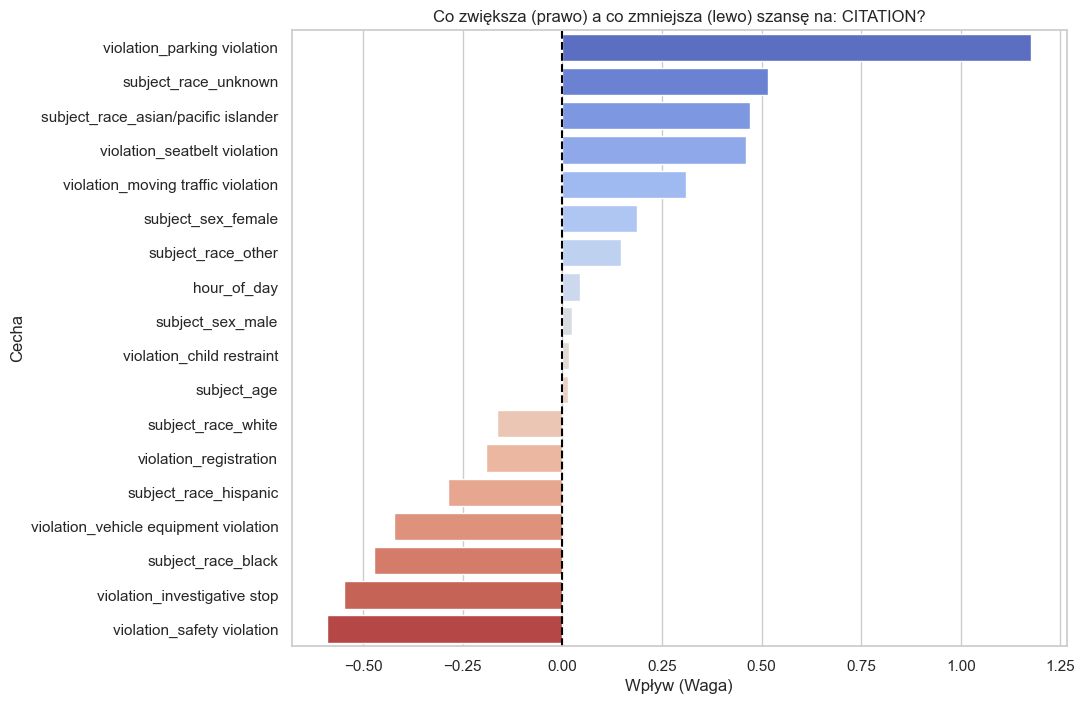

C:\Users\bruno\AppData\Local\Temp\ipykernel_25936\1054223600.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Wpływ (Waga)', y='Cecha', data=coef_df, palette='coolwarm')


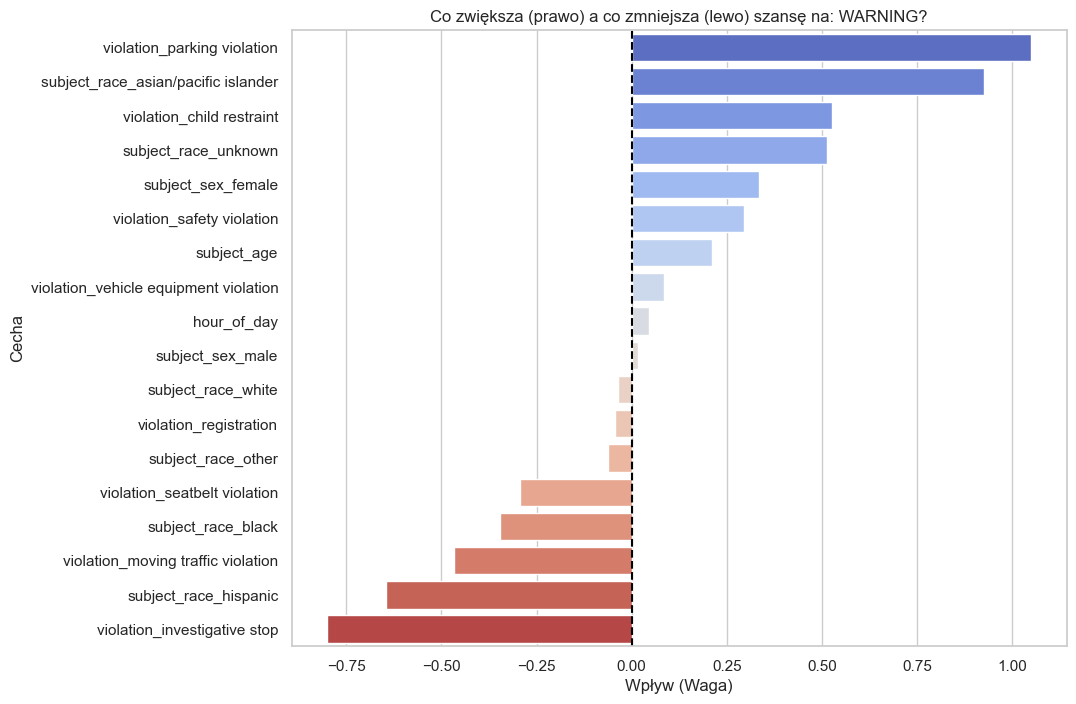

In [5]:
df = pd.read_csv("Data/nashville_sample.csv", low_memory=False)

df["time_obj"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")
df["hour_of_day"] = df["time_obj"].dt.hour

features = ["subject_age", "subject_race", "subject_sex", "hour_of_day", "violation"]
target = "outcome"
df_clean = df[features + [target]].dropna()
X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features = ["subject_age", "hour_of_day"]
categorical_features = ["subject_race", "subject_sex", "violation"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])

model_lr = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("smote", SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

print("Trenowanie Regresji Logistycznej...")
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
print("\n--- Raport Klasyfikacji (Logistic Regression) ---")
print(classification_report(y_test, y_pred))

feature_names = (model_lr.named_steps['preprocessor']
                 .transformers_[1][1]
                 .get_feature_names_out(categorical_features))
all_features = numeric_features + list(feature_names)

# ARESZT
target_class = 'arrest'
class_index = list(model_lr.named_steps['classifier'].classes_).index(target_class)
coefficients = model_lr.named_steps['classifier'].coef_[class_index]

coef_df = pd.DataFrame({'Cecha': all_features, 'Wpływ (Waga)': coefficients})
coef_df = coef_df.sort_values(by='Wpływ (Waga)', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Wpływ (Waga)', y='Cecha', data=coef_df, palette='coolwarm')
plt.title(f'Co zwiększa (prawo) a co zmniejsza (lewo) szansę na: {target_class.upper()}?')
plt.axvline(0, color='black', linestyle='--')
plt.show()

# MANDAT
target_class = 'citation'
class_index = list(model_lr.named_steps['classifier'].classes_).index(target_class)
coefficients = model_lr.named_steps['classifier'].coef_[class_index]

coef_df = pd.DataFrame({'Cecha': all_features, 'Wpływ (Waga)': coefficients})
coef_df = coef_df.sort_values(by='Wpływ (Waga)', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Wpływ (Waga)', y='Cecha', data=coef_df, palette='coolwarm')
plt.title(f'Co zwiększa (prawo) a co zmniejsza (lewo) szansę na: {target_class.upper()}?')
plt.axvline(0, color='black', linestyle='--')
plt.show()

# OSTRZEŻENIE
target_class = 'warning'
class_index = list(model_lr.named_steps['classifier'].classes_).index(target_class)
coefficients = model_lr.named_steps['classifier'].coef_[class_index]

coef_df = pd.DataFrame({'Cecha': all_features, 'Wpływ (Waga)': coefficients})
coef_df = coef_df.sort_values(by='Wpływ (Waga)', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Wpływ (Waga)', y='Cecha', data=coef_df, palette='coolwarm')
plt.title(f'Co zwiększa (prawo) a co zmniejsza (lewo) szansę na: {target_class.upper()}?')
plt.axvline(0, color='black', linestyle='--')
plt.show()

# Anomalie

C:\Users\bruno\AppData\Local\Temp\ipykernel_25936\4294833936.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['contraband_found'] = df['contraband_found'].fillna(False).astype(str) # jako string dla OneHot


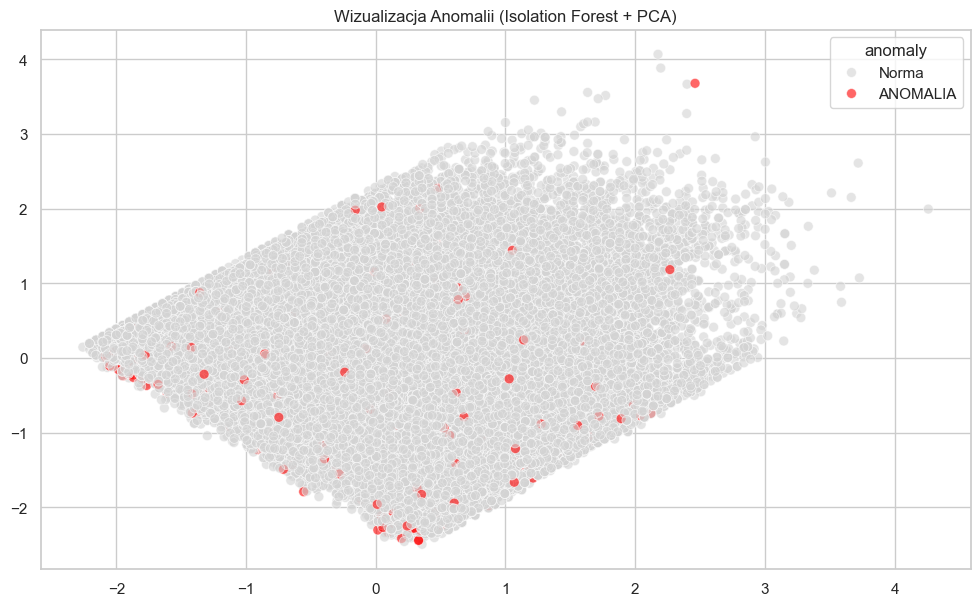


--- Przykłady wykrytych ANOMALII ---
Znaleziono 424 anomalii (0.009945114228080875.
      subject_age  hour                    violation            subject_race  \
134          21.0  21.0  vehicle equipment violation                   black   
240          26.0  10.0           seatbelt violation  asian/pacific islander   
450          23.0  10.0           seatbelt violation                hispanic   
928          54.0  16.0           seatbelt violation                   white   
1090         33.0  20.0  vehicle equipment violation                   white   
1244         45.0  11.0           seatbelt violation                hispanic   
1402         22.0  23.0  vehicle equipment violation                   black   
1488         44.0  10.0           seatbelt violation  asian/pacific islander   
1791         32.0   0.0  vehicle equipment violation                   white   
1856         51.0   3.0  vehicle equipment violation                   white   

     subject_sex   outcome contrab

In [21]:
df = pd.read_csv("Data/nashville_sample.csv", low_memory=False)

df["time_obj"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")
df["hour"] = df["time_obj"].dt.hour
df = df.dropna(subset=["hour"])

features = ["subject_age", "hour", "violation", "subject_race", "subject_sex", "outcome", "contraband_found"]

df['contraband_found'] = df['contraband_found'].fillna(False).astype(str) # jako string dla OneHot
df_anomaly = df[features].dropna()

# 3. Prerocessing (Musimy zamienić wszystko na liczby dla Isolation Forest)
numeric_features = ["subject_age", "hour"]
categorical_features = ["violation", "subject_race", "subject_sex", "outcome", "contraband_found"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_processed = preprocessor.fit_transform(df_anomaly)

iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)

preds = iso_forest.fit_predict(X_processed)

df_anomaly['anomaly_score'] = preds
df_anomaly['anomaly'] = df_anomaly['anomaly_score'].apply(lambda x: 'ANOMALIA' if x == -1 else 'Norma')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(12, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_anomaly['anomaly'], palette={'Norma': 'lightgray', 'ANOMALIA': 'red'}, alpha=0.6, s=50)
plt.title('Wizualizacja Anomalii (Isolation Forest + PCA)')
plt.show()

print("\n--- Przykłady wykrytych ANOMALII ---")
anomalies = df_anomaly[df_anomaly['anomaly'] == 'ANOMALIA']
print(f"Znaleziono {len(anomalies)} anomalii ({len(anomalies)/len(df)}.")
print(anomalies.head(10))

print("\n--- Porównanie średnich: Norma vs Anomalia ---")
print(df_anomaly.groupby('anomaly')[['subject_age', 'hour']].mean())

print("\n--- Najczęstsze wykroczenia wsród anomalii ---")
print(anomalies['violation'].value_counts().head(3))

# Nowy model

In [134]:
df = pd.read_csv('Data/nashville_sample.csv', low_memory=False)

df["time_obj"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")
df["hour"] = df["time_obj"].dt.hour

df['is_night'] = df['hour'].apply(lambda x: 1 if (x >= 22 or x <= 5) else 0)
df['is_young'] = df['subject_age'].apply(lambda x: 1 if x < 25 else 0)

if df['contraband_found'].dtype == 'bool':
    df['contraband_found'] = df['contraband_found'].astype(int)
if df['search_conducted'].dtype == 'bool':
    df['search_conducted'] = df['search_conducted'].astype(int)

df['search_hit'] = df['search_conducted'] * df['contraband_found']

top_violations = df['violation'].value_counts().nlargest(10).index
df['violation_grouped'] = df['violation'].apply(lambda x: x if x in top_violations else 'Other')

df = df.dropna(subset=[target, "hour", "subject_age"])

features = [
    "subject_age", "is_young", "subject_race", "subject_sex",
    "hour", "is_night", "violation_grouped", "search_hit", 'search_conducted']
target = "outcome"

le = LabelEncoder()
df_clean = df[features + [target]].dropna(subset=[target])
df_clean['target_encoded'] = le.fit_transform(df_clean[target])
print("Mapowanie klas:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df_clean[features]
y = df_clean['target_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features = ["subject_age", "hour"]
binary_features = ["is_night", "is_young", "search_hit", "search_conducted"]
categorical_features = ["subject_race", "subject_sex", "violation_grouped"]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

Mapowanie klas: {'arrest': np.int64(0), 'citation': np.int64(1), 'warning': np.int64(2)}


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Najlepsze parametry: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}

Wynik klasyfikacji
              precision    recall  f1-score   support

      arrest       0.33      0.79      0.47       141
    citation       0.35      0.63      0.45      1871
     warning       0.88      0.64      0.74      6507

    accuracy                           0.64      8519
   macro avg       0.52      0.69      0.55      8519
weighted avg       0.75      0.64      0.67      8519



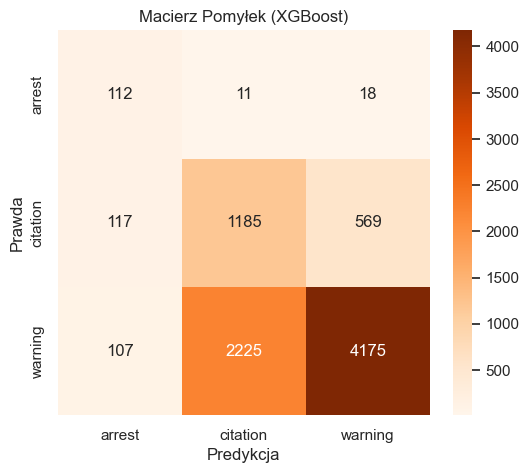

In [138]:
brf = BalancedRandomForestClassifier(
    sampling_strategy='all',
    replacement=True,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', brf)
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [8, 10, 15],
    'classifier__min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Najlepsze parametry: {grid_search.best_params_}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

y_test_names = le.inverse_transform(y_test)
y_pred_names = le.inverse_transform(y_pred)

print("\nWynik klasyfikacji")
print(classification_report(y_test_names, y_pred_names))

cm = confusion_matrix(y_test_names, y_pred_names, labels=le.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Macierz Pomyłek (XGBoost)')
plt.ylabel('Prawda')
plt.xlabel('Predykcja')
plt.show()